# AI Fake News Detection System
## Part 1: Dataset, Exploration, Preprocessing and First Model

This notebook covers the first stage of the implementation:

1. Load the dataset (ISOT Fake and Real News)
2. Explore it: size, balance, text length, sources
3. Check for **data leakage**
4. Clean the text (NLP preprocessing)
5. Convert text to numbers with **TF-IDF**
6. Train a first baseline model and measure it

## 1. Import libraries

In [1]:
import sys, re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

sys.path.append("..")                    # so we can import from src/
from src.preprocess import clean_text    # same cleaning function the web app uses

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (7, 4)

## 2. Load the dataset

The **ISOT Fake and Real News Dataset** has two files: `Fake.csv` (fake articles) and `True.csv` (real articles from Reuters).
Place both files inside the `data/` folder. If they are missing, a small sample file is used so the notebook still runs.

In [2]:
DATA = Path("../data")

if (DATA / "Fake.csv").exists() and (DATA / "True.csv").exists():
    fake = pd.read_csv(DATA / "Fake.csv")
    real = pd.read_csv(DATA / "True.csv")
    USING_REAL_DATA = True
    print("Loaded ISOT dataset")
else:
    print("ISOT files not found: using the tiny sample dataset (results are NOT meaningful)")
    s = pd.read_csv(DATA / "sample_news.csv")
    s["title"] = s["text"].str.split(".").str[0]
    s["subject"], s["date"] = "sample", ""
    fake, real = s[s.label == 0].copy(), s[s.label == 1].copy()
    USING_REAL_DATA = False

print("Fake articles:", fake.shape)
print("Real articles:", real.shape)

Loaded ISOT dataset
Fake articles: (23481, 4)
Real articles: (21417, 4)


### 2.1 First look at the raw data

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,News,"December 25, 2017"


In [4]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for ...",politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits on Monday: Pentagon,WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat tip-off: NYT,WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian diplomat in May 2016 that Russi...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much more' for Amazon shipments,SEATTLE/WASHINGTON (Reuters) - President Donald Trump called on the U.S. Postal Service on Friday to charge “much mo...,politicsNews,"December 29, 2017"


In [5]:
print("Columns:", list(fake.columns))
print()
print("Missing values (fake):\n", fake.isnull().sum())
print("\nMissing values (real):\n", real.isnull().sum())
print("\nDuplicate articles: fake =", fake.duplicated().sum(), "| real =", real.duplicated().sum())

Columns: ['title', 'text', 'subject', 'date']

Missing values (fake):
 title      0
text       0
subject    0
date       0
dtype: int64

Missing values (real):
 title      0
text       0
subject    0
date       0
dtype: int64

Duplicate articles: fake = 3 | real = 206


## 3. Label and combine

We add a `label` column: **0 = fake**, **1 = genuine**. Then we merge both files, combine the title and text into one field,
and shuffle the rows.

In [6]:
fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real], ignore_index=True)
df = df.drop_duplicates(subset="text")
df["full_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
df = df[df["full_text"].str.strip().str.len() > 0]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total articles after removing duplicates and empty rows:", len(df))
df[["title", "label"]].head()

Total articles after removing duplicates and empty rows: 38646


,title,label
0,Kenya watchdog says investigating police over actions at university,1
1,"Trump bars door to refugees, visitors from seven mainly Muslim nations",1
2,"Kosovo parties sign deal to form government, end political deadlock",1
3,Trump says no 'rush' to get healthcare legislation done next week,1
4,Letter To The Editor Claims Hillary Is Unfit Because She Might Get Her Period (IMAGE),0


## 4. Exploratory data analysis

### 4.1 Is the dataset balanced?

label
Fake       17455
Genuine    21191
Name: count, dtype: int64


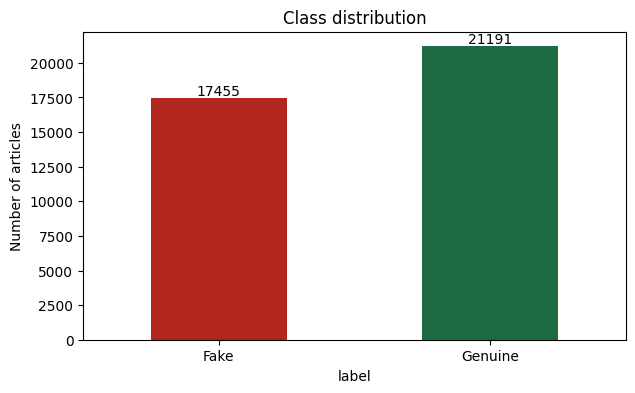

In [7]:
counts = df["label"].value_counts().sort_index()
print(counts.rename({0: "Fake", 1: "Genuine"}))

ax = counts.plot(kind="bar", color=["#b3261e", "#1d6b43"])
ax.set_xticklabels(["Fake", "Genuine"], rotation=0)
ax.set_ylabel("Number of articles")
ax.set_title("Class distribution")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

### 4.2 Article length (number of words)

           count   mean    std   min    25%    50%    75%     max
label                                                            
Fake     17455.0  439.6  355.4   2.0  291.0  390.0  517.0  8148.0
Genuine  21191.0  394.8  273.7  29.0  157.5  368.0  533.0  5181.0


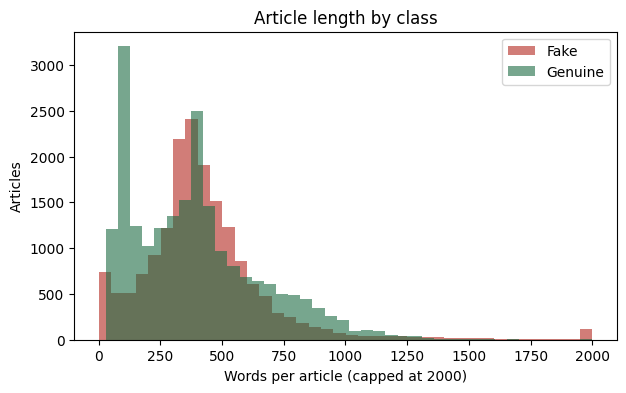

In [8]:
df["word_count"] = df["full_text"].str.split().str.len()
print(df.groupby("label")["word_count"].describe().rename(index={0: "Fake", 1: "Genuine"}).round(1))

for lab, name, col in [(0, "Fake", "#b3261e"), (1, "Genuine", "#1d6b43")]:
    plt.hist(df.loc[df.label == lab, "word_count"].clip(upper=2000), bins=40, alpha=.6, label=name, color=col)
plt.xlabel("Words per article (capped at 2000)")
plt.ylabel("Articles")
plt.title("Article length by class")
plt.legend()
plt.show()

### 4.3 Subject categories

In [9]:
pd.crosstab(df['subject'], df['label'].map({0: 'Fake', 1: 'Genuine'}))

label,Fake,Genuine
subject,,
Government News,514,0
News,9050,0
US_News,783,0
left-news,683,0
politics,6425,0
politicsNews,0,11213
worldnews,0,9978


### 4.4 Read some examples

In [10]:
print("FAKE examples\n" + "-" * 60)
for t in df[df.label == 0]["title"].head(5): print("•", t)
print("\nGENUINE examples\n" + "-" * 60)
for t in df[df.label == 1]["title"].head(5): print("•", t)

FAKE examples
------------------------------------------------------------
•  Letter To The Editor Claims Hillary Is Unfit Because She Might Get Her Period (IMAGE)
• BREAKING: SCREW THE FRONT-RUNNERS Chosen By “We The People”…The GOP Establishment Has Other Plans
•  Longtime GOP Consultant Throws His Party Under The Bus By Explaining Voter ID Laws
• DETROIT COP UNDER FIRE FOR FACEBOOK POST: “The only racists here are the piece of (expletive) Black Lives Matter terrorists and their supporters” [VIDEO]
• KILLING AMERICAN WORKERS By Replacing With Foreign Workers…Michelle Malkin Speaks To Abbott Lab’s Replaced Workers [Video]

GENUINE examples
------------------------------------------------------------
• Kenya watchdog says investigating police over actions at university
• Trump bars door to refugees, visitors from seven mainly Muslim nations
• Kosovo parties sign deal to form government, end political deadlock
• Trump says no 'rush' to get healthcare legislation done next week
• U.S. co

## 5. Data leakage check

A model can score very high for the wrong reason, if the dataset contains a hidden clue that gives away the label.
In ISOT, genuine articles come from Reuters and usually include the word **"Reuters"**. Let us check.

In [11]:
has_reuters = df["full_text"].str.contains("reuters", case=False)
print("Share of articles mentioning 'Reuters':")
print(has_reuters.groupby(df["label"].map({0: "Fake", 1: "Genuine"})).mean().mul(100).round(1).astype(str) + " %")

Share of articles mentioning 'Reuters':
label
Fake        1.3 %
Genuine    99.8 %
Name: full_text, dtype: object


If almost all genuine articles contain "Reuters" and almost no fake ones do, the model would just learn that one word.
That would not help on real-world news from other sources.
**Fix:** our `clean_text()` function removes the word "Reuters" before training.

## 6. Text preprocessing (NLP)

Cleaning steps in `src/preprocess.py`:
- remove HTML tags and URLs
- remove the "Reuters" source tag
- convert to lowercase
- remove punctuation and digits
- normalise spaces

Stop words (the, is, and ...) are removed later by the TF-IDF vectorizer.

In [12]:
sample = df["full_text"].iloc[0]
print("BEFORE:\n", sample[:400])
print("\nAFTER:\n", clean_text(sample)[:400])

BEFORE:
 Kenya watchdog says investigating police over actions at university  (This September 29 has been corrected to fix date of election in paragraph 3) NAIROBI (Reuters) - A Kenyan government watchdog said on Friday it was investigating whether police had assaulted students during protests this week at the University of Nairobi over the detention of an opposition lawmaker.   Police fired tear gas on Th

AFTER:
 kenya watchdog says investigating police over actions at university this september has been corrected to fix date of election in paragraph nairobi a kenyan government watchdog said on friday it was investigating whether police had assaulted students during protests this week at the university of nairobi over the detention of an opposition lawmaker police fired tear gas on thursday at the protestin


In [13]:
df["clean_text"] = df["full_text"].map(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print("Cleaned", len(df), "articles")
df[["clean_text", "label"]].head()

Cleaned 38641 articles


,clean_text,label
0,kenya watchdog says investigating police over actions at university this september has been corrected to fix date of...,1
1,trump bars door to refugees visitors from seven mainly muslim nations washington cairo five iraqi passengers and one...,1
2,kosovo parties sign deal to form government end political deadlock pristina kosovo s center right coalition led by t...,1
3,trump says no rush to get healthcare legislation done next week washington president donald trump said on friday the...,1
4,letter to the editor claims hillary is unfit because she might get her period image a pennsylvania man apparently fa...,0


In [14]:
# Save the cleaned dataset for later steps (only when the real dataset was used)
if USING_REAL_DATA:
    df[["full_text", "label"]].rename(columns={"full_text": "text"}).to_csv(DATA / "news_clean.csv", index=False)
    print("Saved data/news_clean.csv")
else:
    print("Sample data in use: not saving")

Saved data/news_clean.csv


### 6.1 Most frequent words in each class (after cleaning, without stop words)

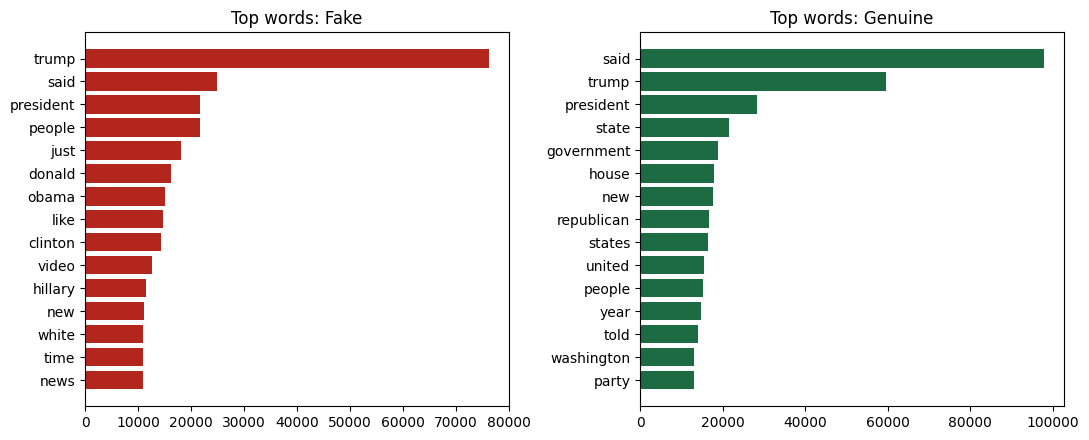

In [15]:
def top_words(texts, n=15):
    c = Counter()
    for t in texts:
        c.update(w for w in t.split() if w not in ENGLISH_STOP_WORDS and len(w) > 2)
    return c.most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (lab, name, col) in zip(axes, [(0, "Fake", "#b3261e"), (1, "Genuine", "#1d6b43")]):
    words, freq = zip(*top_words(df.loc[df.label == lab, "clean_text"]))
    ax.barh(words[::-1], freq[::-1], color=col)
    ax.set_title(f"Top words: {name}")
plt.tight_layout()
plt.show()

## 7. Feature extraction with TF-IDF

Machine learning models need numbers, not words. **TF-IDF** (Term Frequency, Inverse Document Frequency) scores each word:
- high if the word appears often in *this* article
- low if the word appears in *every* article (like "said")

We use single words and two-word phrases (n-grams 1 to 2), and keep the 30,000 most useful features.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"])

print("Training articles:", len(X_train))
print("Testing articles: ", len(X_test))

vec = TfidfVectorizer(stop_words="english", max_features=30000, ngram_range=(1, 2), sublinear_tf=True)
Xtr = vec.fit_transform(X_train)     # learn vocabulary from TRAINING data only
Xte = vec.transform(X_test)

print("\nTF-IDF matrix shape (articles x features):", Xtr.shape)
print("Example features:", list(vec.get_feature_names_out()[:15]))

Training articles: 30912
Testing articles:  7729

TF-IDF matrix shape (articles x features): (30912, 30000)
Example features: ['aa', 'aadhaar', 'aapl', 'aaron', 'ab', 'aback', 'abadi', 'abadi said', 'abandon', 'abandoned', 'abandoning', 'abbas', 'abbasi', 'abbott', 'abby']


## 8. First baseline model: Logistic Regression

A simple, fast model to check that the pipeline works. In the next stage we compare it with Naive Bayes and Random Forest.

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(Xtr, y_train)
pred = model.predict(Xte)

print("Accuracy :", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 4))
print("F1-score :", round(f1_score(y_test, pred, zero_division=0), 4))
print()
print(classification_report(y_test, pred, target_names=["Fake", "Genuine"], zero_division=0))

Accuracy : 0.9876
Precision: 0.983
Recall   : 0.9946
F1-score : 0.9887

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3490
     Genuine       0.98      0.99      0.99      4239

    accuracy                           0.99      7729
   macro avg       0.99      0.99      0.99      7729
weighted avg       0.99      0.99      0.99      7729



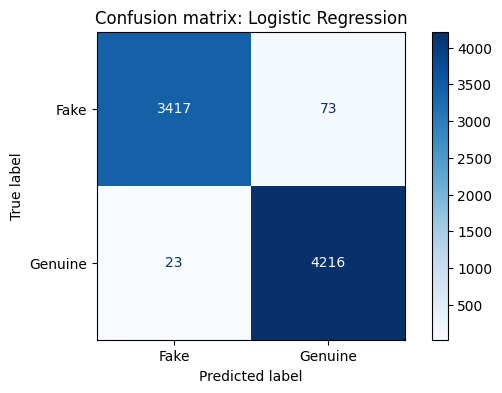

In [18]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["Fake", "Genuine"]).plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix: Logistic Regression")
plt.show()

### 8.1 Which words does the model rely on?

In [ ]:
features = np.array(vec.get_feature_names_out())
order = np.argsort(model.coef_[0])
print("Words pointing to FAKE   :", ", ".join(features[order[:15]]))
print("Words pointing to GENUINE:", ", ".join(features[order[-15:]][::-1]))

### 8.2 Try it on a custom sentence

In [ ]:
def quick_predict(text):
    p_fake, p_real = model.predict_proba(vec.transform([clean_text(text)]))[0]
    label = "Likely Genuine" if p_real >= p_fake else "Likely Fake"
    return label, round(max(p_fake, p_real) * 100, 1)

print(quick_predict("SHOCKING: secret video exposed, the media is hiding the truth, share before they delete this"))
print(quick_predict("The finance ministry said on Tuesday that the budget proposal will be reviewed by lawmakers next month"))